<a href="https://colab.research.google.com/github/marinaalfarias/ia940/blob/main/Envoltoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

import librosa


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
fname = '/content/drive/MyDrive/Educacao/EE940/2020S2/Notebooks/Sons/Piano.mf.A3.aiff'
x, sr = librosa.load(fname, sr=None, mono=True)

/tmp/ipykernel_680/2853095188.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  x, sr = librosa.load(fname, sr=None, mono=True)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Educacao/EE940/2020S2/Notebooks/Sons/Piano.mf.A3.aiff'

# Forma de onda

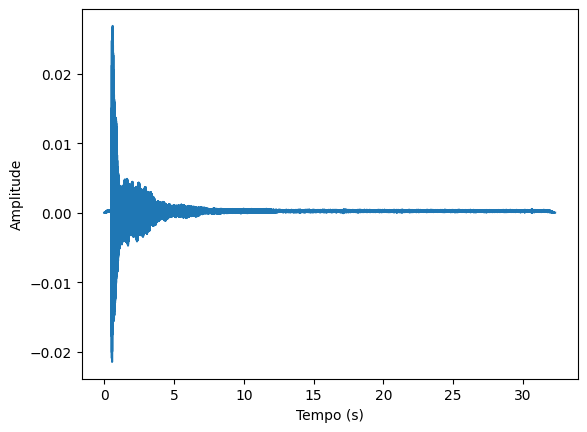

In [ ]:
t = np.linspace(0, len(x)/sr, len(x))
plt.figure()
plt.plot(t,x)
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.show()

# Envoltórias

In [ ]:
def rms(_x):
  return np.sqrt(np.mean(_x**2))

In [ ]:
def max(_x):
  return np.max(np.abs(_x))

In [ ]:
def env(x, frame_len, func=rms):
  i = 0
  e = []
  while (i+1)*frame_len < len(x):
    rms_local = func(x[i*frame_len : (i+1)*frame_len])
    e.append(rms_local)
    i += 1

  e = np.array(e)
  return e

In [ ]:
er = env(x, 1024, rms)
em = env(x, 1024, max)

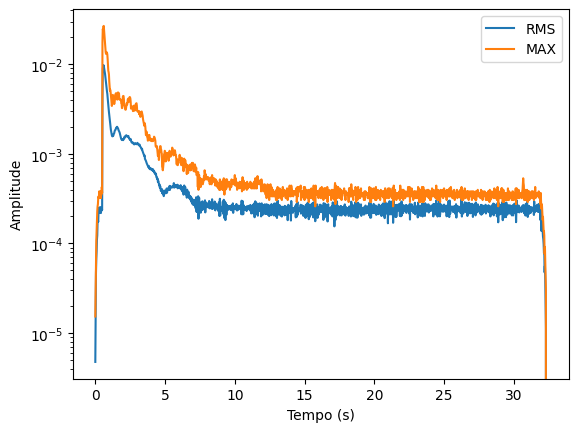

In [ ]:
te = np.linspace(0, len(x)/sr, len(er))
plt.figure()
plt.plot(te, er, label='RMS')
plt.plot(te, em, label='MAX')
plt.legend()
plt.semilogy()
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.show()

# Mostrando forma de onda e envoltória

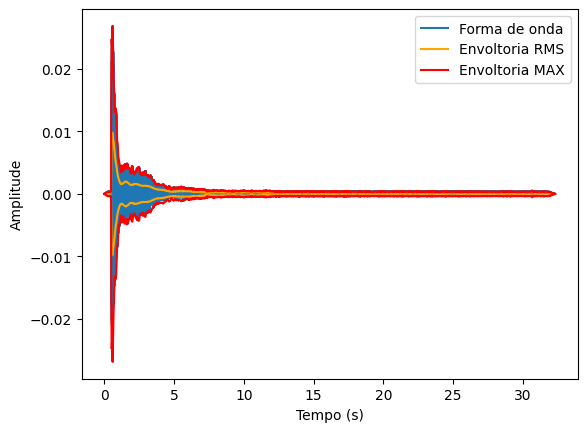

In [ ]:
t = np.linspace(0, len(x)/sr, len(x))
plt.figure()
plt.plot(t,x, label='Forma de onda')
plt.plot(te, er, color='orange', label='Envoltoria RMS')
plt.plot(te, -er, color='orange')
plt.plot(te, em, color='red', label='Envoltoria MAX')
plt.plot(te, -em, color='red')
plt.legend()
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.show()